In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

from LSSVMClassification import LSSVMClassification
from sklearn.datasets import load_iris

In [12]:
# Stap 1: Iris inladen
iris = load_iris()

X = iris.data
y = iris.target

mask = y != 2 #nu classifier ondersteunt enkel binaire classificatie

X = X[mask]
y = y[mask]

y = np.where(y == 0, -1, 1)

print(np.unique(y))

[-1  1]


In [13]:
# Stap 2: Train-test split 120 trainingspunten en 30 testpunten
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

In [14]:
# Stap 3: classifier trainen
model = LSSVMClassification(
    gamma=1.0,
    kernel="rbf",
    sigma=1.0
)

model.fit(X_train, y_train)


In [15]:
# Stap 4: Prediction
model = LSSVMClassification(
    gamma=1.0,
    kernel='rbf',
    sigma=1.0
)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(pred)

[ 1.  1.  1.  1. -1. -1. -1.  1. -1. -1. -1.  1. -1. -1. -1.  1.  1. -1.
  1.  1.]


In [16]:
# Stap 5: Correcte voorspellingen check? 
print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))

Accuracy: 1.0
[[10  0]
 [ 0 10]]


In [17]:
# Extra volgens AI: model vergelijken met classifier sklearn
from sklearn.svm import SVC
svc = SVC(kernel="rbf", C=1.0, gamma=1.0)

svc.fit(X_train, y_train)

pred_svc = svc.predict(X_test)

print("LS-SVM :", accuracy_score(y_test, pred))
print("SVC    :", accuracy_score(y_test, pred_svc))


LS-SVM : 1.0
SVC    : 1.0


Accuracy: 1.000


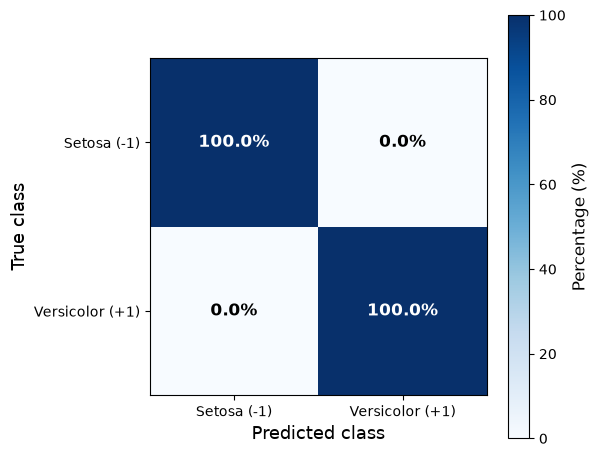

In [19]:
print(f"Accuracy: {accuracy_score(y_test, pred):.3f}")

cm = confusion_matrix(y_test, pred)

cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(cm_percent,
               cmap="Blues",
               vmin=0,
               vmax=100)

# colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Percentage (%)", fontsize=12)

classes = ["Setosa (-1)", "Versicolor (+1)"]

ax.set_xticks(np.arange(2))
ax.set_yticks(np.arange(2))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

ax.set_xlabel("Predicted class", fontsize=13)
ax.set_ylabel("True class", fontsize=13)

for i in range(2):
    for j in range(2):
        ax.text(j,
                i,
                f"{cm_percent[i,j]:.1f}%",
                ha="center",
                va="center",
                color="white" if cm_percent[i,j] > 50 else "black",
                fontsize=12,
                fontweight="bold")

plt.tight_layout()
plt.show()

In [20]:
print(classification_report(
    y_test,
    pred,
    target_names=["Setosa","Versicolor"]
))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

